<h1 style="text-align: center;">ANÁLISIS Y PROCESAMIENTO DE SEÑALES</h1>

<center>
    
### 1er cuatrimestre 2026
</center>

<p style="text-align: center;">Muñoz Jazmín Ayelén</p>

<h3 style="text-align;">INTRODUCCIÓN</h3>

En este trabajo se abordará la síntesis de señales discretas en el tiempo, como así también el análisis correspondiente mediante la aplicación de conceptos fundamentales para el procesamiento digital de señales. 


En el primer ejercicio se generaránn distintas señales a partir de una señal senoidal base de 2000Hz al cual se le aplicarán distintas modificaciones como lo son el cambio de fase, la ampliación en decibeles de la amplitud, la saturación, entre otros. Además, se sintetizarán otro tipos de señales, como una señal cuadrada o un pulso rectangular. En cada caso se determinarán los parámetros fundamentales, como el período, el número de muestras en función de la frecuencia de muestreo, etc. 

En el segundo ejercicio, se analizará la respuesta de un sistema lineal invariante en el tiempo, caracterizado por su respuesta al impulso y se calculará la salida mediante el producto de convolución. 

<h3 style="text-align;">EJERCICIO 1</h3>

1. Señal sinusoidal de 2 KHz.

A. En una primera instancia, desarrollé la expresión matemática en papel, con el fin de analizar el comportamiento de la señal.

![Resolución del primer inciso.](imagen1.jpeg)

En python, desarrollarlo únicamente con 4 muestras, no tiene sentido, así que eso lo vamos a cambiar, aumentándole la frecuencia de muestreo. 

B. En segunda instanta, hice la sintetización de la señal en Python.

In [10]:
#Creo el bloque para hacer la función 
import numpy as np
def mi_funcion_sen(vmax, dc, ff, ph, nn,fs): #Vmax es la amplitud, dc el valor de continua, ff la frecuencia,
    # ph la faso, nn numero de muestras, y fs recuencia de muestreo.  
    # El tiempo de muestreo.
    ts=1/fs
    #Creo el vector de tiempo. 
    # Generamos un vector de numeros que tengan la misma cantidad que de muestras, ahora lo tengo que multiplicar por ts, para obtener tt
    x = np.arange(nn)
    #En Chat GPT, sirve para asegurarme que tengo una sola columna, es (filas, columnas) el -1 hace que se rellene automáticamentela cant filas. 
    tt=x*ts 
    #Ahora sí, hago la señal senoidal. 
    xx = vmax*np.sin(2*np.pi*ff*tt+ph) + dc
    return tt,xx

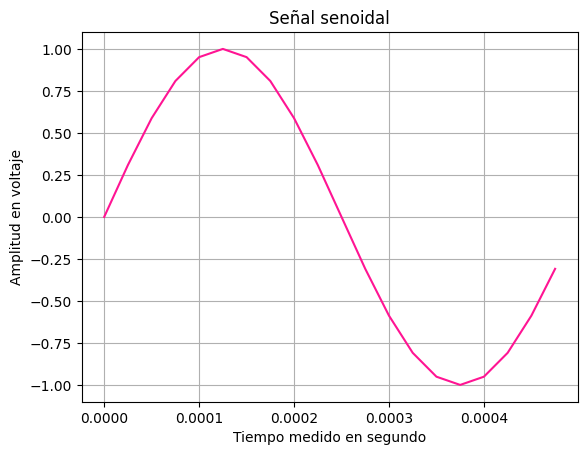

In [11]:
#Llamo a la funcion y hago el grafico
import matplotlib.pyplot as plt #matplotlib es la librería para graficar, pyplot es el modulo que tiene las erramientas graficas. 
#Y después el plt es un nombre que ponemos para no tener que escribir el entero. 
T=1/2000 #Me piden trabajar en un período. 
fs=40000 #Para respetar Nyquist, pongo mayor a 4KHz, 
ts=1/fs
N=int(T/ts)
#Llamo a la función, la escribo como tt,xx
tt,xx = mi_funcion_sen(vmax=1, dc=0, ff=2000, ph=0, nn=N, fs=fs)
plt.plot(tt, xx , color= 'deeppink') #Acá dibuja la función que creamos. 
plt.xlabel("Tiempo medido en segundo")
plt.ylabel("Amplitud en voltaje")
plt.title("Señal senoidal")
plt.grid(True) # Ponemos una grilla
plt.show() #Esto muestra en pantalla el gráfico.

Se observa un período de una señal senoidal de frecuencia 2kHz, generada a partir de una frecuencia de muestreo de 40KHz. El período de la señal es T = 0.5 ms y se obtiene un total de 20 muestras por período. 

La señal presenta un comportamiento periódico, con amplitud constante y sin componente de continua. Debido a la periodicidad en el tiempo, se clasifica como una señal de potencia, ya que su energía total es infinita. 

2. Misma señal amplificada 3 dB y desfasada en π/2.

A. En una primera instancia, desarrollé la expresión matemática en papel, con el fin de analizar el comportamiento de la señal modificada.

![Resolución del primer inciso.](imagen2.jpeg)

B. En segunda instanta, hice la sintetización de la señal en Python.

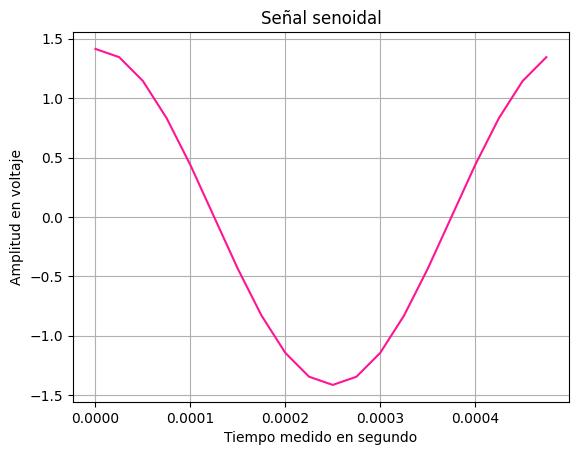

Período: 0.0005 segundos
Número de muestras: 20
Es una señal periódica aún, ya que es la misma senoidal original pero desfasada, por lo tanto es una señal de potencia


In [32]:
T=1/2000 #Me piden trabajar en un período. 
fs=40000 #Para respetar Nyquist, pongo mayor a 4KHz, 
ts=1/fs
N=int(T/ts)
phh=np.pi/2 #La senoidal arrancará en el máximo, por estar desafasada.
vmaxmod=1*1.414 #Raiz de dos para aumentarle los 3db. 
#Llamo a la función, la escribo como tt,xx
tt,xx = mi_funcion_sen(vmax=vmaxmod, dc=0, ff=2000, ph=phh, nn=N, fs=fs)
plt.plot(tt, xx , color= 'deeppink') #Acá dibuja la función que creamos. 
plt.xlabel("Tiempo medido en segundo")
plt.ylabel("Amplitud en voltaje")
plt.title("Señal senoidal")
plt.grid(True) # Pongo una grilla
plt.show() #Esto muestra en pantalla el gráfico.

#Escribo los parámetros que me pedían
print("Período:", T, "segundos")
print("Número de muestras:", N)
print("Es una señal periódica aún, ya que es la misma senoidal original pero desfasada, por lo tanto es una señal de potencia")

En un solo período no podemos observar la señal senoidal persé, ya que debido al desfasaje, arranca en el máximo. 

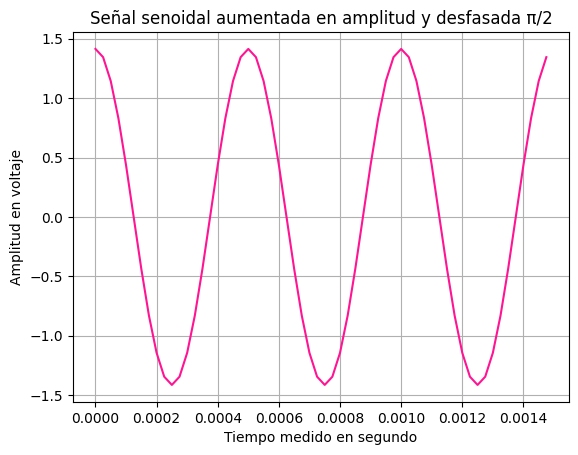

In [13]:
num_periodos = 3
T = 1/2000
fs=40000 #Para respetar Nyquist, pongo mayor a 4KHz, 
ts=1/fs
N = int(num_periodos*T/ts)
tt, xx = mi_funcion_sen(vmax=vmaxmod, dc=0, ff=2000, ph=phh, nn=N, fs=fs)
phh=np.pi/2
vmaxmod=1*1.414
#Llamo a la función, la escribo como tt,xx
tt,xx = mi_funcion_sen(vmax=vmaxmod, dc=0, ff=2000, ph=phh, nn=N, fs=fs)
plt.plot(tt, xx , color= 'deeppink') #Acá dibuja la función que creamos. 
plt.xlabel("Tiempo medido en segundo")
plt.ylabel("Amplitud en voltaje")
plt.title("Señal senoidal aumentada en amplitud y desfasada π/2")
plt.grid(True) # Ponemos una grilla
plt.show() #Esto muestra en pantalla el gráfico.

En esta imagen se observa mejor el aumento en la amplitud, además del desfasaje.

3. Misma señal modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz.

Cuando se tiene una señal modulada en amplitud por otra, básicamente estamos frente a la combinación de dos señales, la portadora y la moduladora. 
La señal portadora, es la señal de alta frecuencia que transporta la información, suele ser una senoidal pura y en nuestro caso es la señal original de frecuencia 2KHz.
  La moduladora contiene la información que se desea transmitir y su forma es la que modifica a la portadora, en nuestro caso es la señal sinusoidal de 1KHz.   De esta manera se obtiene una señal modulada en amplitud donde la amplitud de la portadora sigue la forma de la moduladora. 
  Esto puede observarse esquemáticamente en la siguiente imagen y resulta útil, pues se supone que debemos obtener algo parecido una vez sintetizada ambas señales. 

<div style="text-align: center;">
    <img src="imagen3.jpeg" alt="texto alternativo" width="400">
</div>

La fórmula general de una señal modulada en amplitud (AM) es:

$$
x_{\mathrm{AM}}(t) = \big[ A_m \cdot m(t) + A_c \big] \cdot \cos(2 \pi f_c t + \phi_c)
$$

Donde:

- Ac es la amplitud de la portadora  
- fc es la frecuencia de la portadora  
- phi es la  fase inicial de la portadora  
- m(t) es la señal moduladora, que contiene la información.  
- Am es la amplitud de la moduladora, es decir la  profundidad de modulación.

Sintetización de la señal en Python.

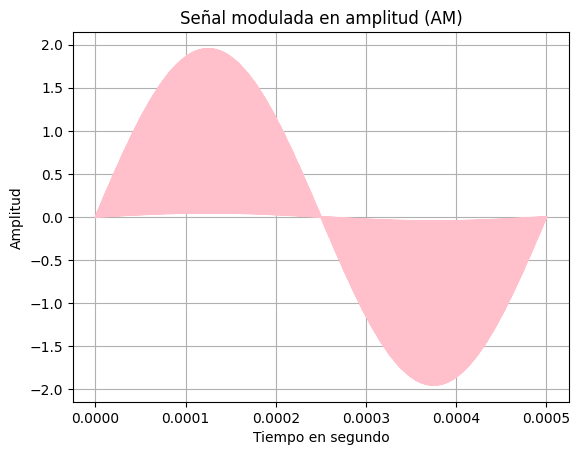

Período de la  portadora: 0.0005
Número de muestras: 5000
La señal AM es periódica, por lo tanto es una señal de potencia


In [27]:
# Parámetros
fs = 10_000_000  # 10 MHz, en realidad para respetar Nyquist, bastaría con que pusiera 2MHz, ya que fs>=2*fmax, y fmax es 1MHz, pero me daba diferente
f_portadora = 2000  
f_moduladora = 1_000_000  
T = 1/f_portadora #Calculo el período de la portadora. 
N = int(T*fs) #Acá calculo al cantidad de muestra en un período de la poradora, o sea cuántos puntitos voy a tener para graficar.  

# Señal portadora
tt, x_portadora = mi_funcion_sen(vmax=1, dc=0, ff=f_portadora, ph=0, nn=N, fs=fs) #La portadora es la del seno de 2khz, o sea la origianl. 

# Señal moduladora
tt, x_moduladora = mi_funcion_sen(vmax=1, dc=0, ff=f_moduladora, ph=0, nn=N, fs=fs)

# Señal AM
x_AM = (1 + x_moduladora) * x_portadora #(1 + x_moduladora) con esto cambio la amplitud y luego la multiplico por la portadora. 

# Gráfico
plt.plot(tt, x_AM, color='pink')
plt.xlabel("Tiempo en segundo")
plt.ylabel("Amplitud")
plt.title("Señal modulada en amplitud (AM)")
plt.grid(True)
plt.show()

#Escribo los datos que me pedían. 
print("Período de la  portadora:", T)
print("Número de muestras:", N)
print("La señal AM es periódica, por lo tanto es una señal de potencia") 

Se observa toda la zona pintada a simple vista, debido a que la amplitud cambia demasiado rápido para poder ser percibida de forma adecuada en el tiempo, si se pudiera hacer zoom, se podría observar a la señal senoidal de frecuencia mayor. 

4. Misma señal con efecto de saturación al 75% de su amplitud.

Antes de la corrección de consigna, yo había planteado ambos casos frente a la ambigüedad de la consigna, dejo ambos en la parte desarrolada en papel y a la hora de hacer la simulación, hago solo el clipeo.

A. Desarrollo de la expresión matemática en papel.

![Resolución del primer inciso.](imagen4.jpeg)

![Resolución del primer inciso.](imagen5.jpeg)

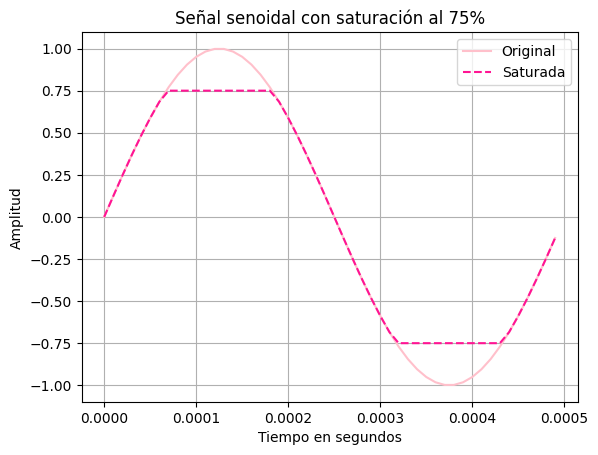

Período: 0.0005 segundos
Número de muestras: 50
La señal senoidal con saturación al 75% es periódica, por lo tanto es una señal de potencia


In [24]:
fs = 100_000
f = 2000 #Sigo teniendo la misma frecuencia de la señal.
T = 1/f #Con esto calculo el período, porque me pedían uno solo. 
N = int(T*fs) #Acá calculo el número de muestras. 

tt = np.arange(N)/fs #Creo el vector de tiempo.

# Señal original
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=f_portadora, ph=0, nn=N, fs=fs)
# Determino la saturación al 75%
x_sat = np.clip(xx, -0.75, 0.75) #Esta parte hace lo que yo escribí en papel arriba, si x > 0.75, lo deja en 0.75 y lo mismo con el -0.75.

# Gráfico
plt.plot(tt, xx,color='pink', label="Original")
plt.plot(tt, x_sat, color='deeppink', label="Saturada", linestyle='--') #Busqué cómo hacer una linea punteada para que se observe mejor, y me dio ese comando. 
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud")
plt.title("Señal senoidal con saturación al 75%")
plt.legend()
plt.grid(True)
plt.show()

#Agrego las cositas que me preguntaban, aunque redundante para facilitar la visualización. 
print("Período:", T, "segundos")
print("Número de muestras:", N)
print("La señal senoidal con saturación al 75% es periódica, por lo tanto es una señal de potencia") 


Se puede observar en el gráfico que cuando la señal se halla por encima del límite fijado para su amplitud, esta se clipea, es decir que se recorta fijándolo en dicha cota. Esto se repite nuevamente en la parte inferior, dando como resultado final una señal con forma diferente a la original. Esta es la principal diferencia entre clippear y escalar, como vimos en la parte que realicé en papel. 

Sin embargo, sigue siendo una señal de potencia, debido a que sigue siendo de carácter periódico ya que su base consiste en una senoidal.

5. Una señal cuadrada de 4KHz.

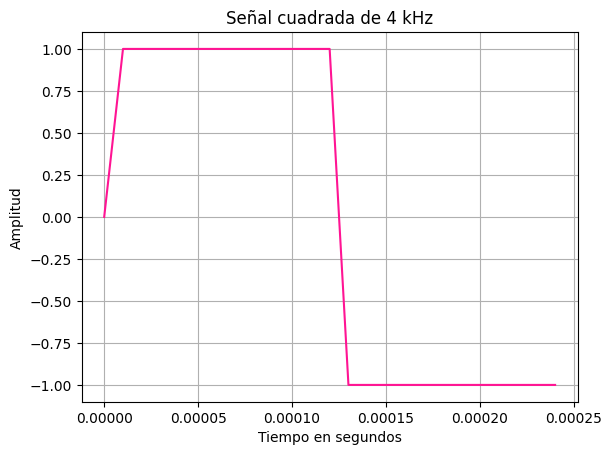

Período: 0.00025 segundos
Número de muestras: 25
Es una señal periódica a pesar de ya no ser nuestra senoidal base, por lo tanto sigue siendo una serie de potencia.


In [36]:
# Parámetros
f = 4000
T = 1/f
fs = 100000  # mayor a 8 kHz por NyQUIST.
ts = 1/fs
N = int(T/ts)

# Tiempo
tt = np.arange(N)/fs

# Señal cuadrada
xx = np.sign(np.sin(2*np.pi*f*t)) #Esta línea me la explicó el profe Mariano en clase.

# Gráfico

plt.plot(tt, xx, color='deeppink')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud")
plt.title("Señal cuadrada de 4 kHz")
plt.grid(True)
plt.show()

#Los datos que me piden.

print("Período:", T, "segundos")
print("Número de muestras:", N)
print("Es una señal periódica a pesar de ya no ser nuestra senoidal base, por lo tanto sigue siendo una serie de potencia.")

$$
xx = \mathrm{sign}(\sin(2\pi f t))
$$
Esta línea me la explicó el profe Mariano en clase, como el seno sube y baja, lo que hace sign es convertirlo en -1 si es negativo o 1 si es positivo,
o sea que obtenemos una señal que salta de -1 a 1 y viceversa, dando esa forma de escalón que podemos visualizar en el gráfico.


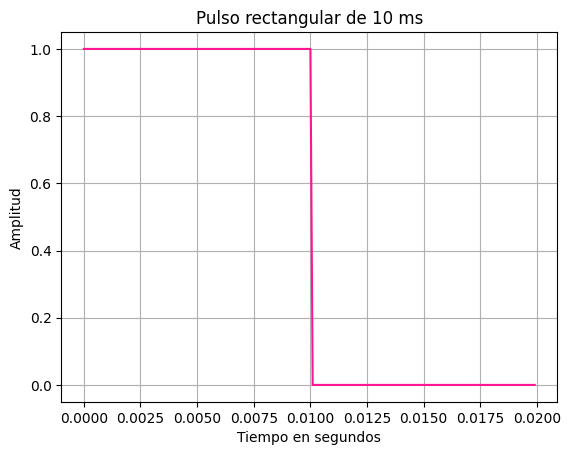

Duración del pulso: 0.01 segundos
Número de muestras: 200
Es una señal de energía, ya que no es periódica


In [40]:
# Parámetros
fs = 10000  # frecuencia de muestreo
ts = 1/fs
duracion = 0.01  # 10 ms

# Tiempo total (un poco más grande para ver el pulso)
t = np.arange(0, 0.02, ts)

# Pulso rectangular
x = np.where(t <= duracion, 1, 0)

# Gráfico
plt.plot(t, x, color='deeppink')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud")
plt.title("Pulso rectangular de 10 ms")
plt.grid(True)
plt.show()

# Los datos: 

print("Duración del pulso:", duracion, "segundos")
print("Número de muestras:", len(t))
print("Es una señal de energía, ya que no es periódica")

# No estaba muy segura de cómo realizar esta parte porque no la vimos, tuve que buscarlo así que por eso tiene partes raras, borré muchas cosas que no entendía y que parecían innecesarias.  

El pulso rectangular que generamos es una señal no periódica, por lo que es la única señal de energía de la TS. En la materia de Medidas, vimos que si se repite este pulso periódicamente mediante un generador de señales, puede caracterizarse a través de su ciclo de trabajo (duty). Entonces, en dicho caso, la señal pasaría a tener energía infinita debido a la periodicidad, y pasaría a ser también una señal de potencia. 

<h3 style="text-align;">EJERCICIO 2</h3>

Dada la secuencia:

$$
h[n] = \delta[n] - \delta[n - 4]
$$

encontrar la salida:

$$
y[n] = x[n] * h[n]
$$

para cada una de las siguientes señales de entrada $x[n]$.

**A) Sea la señal de entrada:**

$$
x[n] = \cos(\omega_0 \, n \, T_S)
$$

Expresar la salida del sistema:

$$
y[n] = x[n] * h[n]
$$

como un único coseno de la forma:

$$
y[n] = A \cos(\omega_0 \, n \, T_S + \varphi)
$$

![Resolución del primer inciso.](imagen6.jpeg)

Resulta relevante hacer un análisis de esto mediante la sintetización en Python,para ver si efectivamente tal como se observa en papel, el sistema solo modifica la amplitud y la fase, dejando constante la frecuencia. 

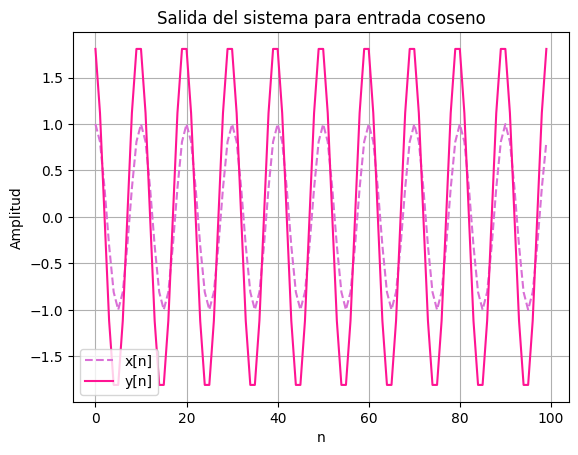

In [55]:
# Parámetros
n = np.arange(0, 100)   # tiempo discreto
w0 = 0.2 * np.pi        # Elijo un valor cualquiera para la frecuencia. 
Ts = 1                  # tiempo de muestreo

# Armo la señal de entrada
x = np.cos(w0 * n * Ts)

# creo la señal desplazada
x_shift = np.cos(w0 * (n - 4) * Ts)

# La convolución es:
y = x - x_shift

# Gráfico
plt.plot(n, x, label="x[n]", color='orchid', linestyle='--')
plt.plot(n, y, label="y[n]", color='deeppink')
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Salida del sistema para entrada coseno")
plt.legend()
plt.grid()
plt.show()

Podemos observar que las dos señales, la de entrada y salida, poseen la misma frecuencia. Sin embargo, se puede observar una diferencia en la amplitud como así también el corrimiento de fase, lo que nos permite confirmar que el sistema actúa alterando la fase y la amplitud, pero no su frecuencia, que es lo que había comentado Mariano en las primeras clases.

**B) Sea la señal de entrada:**

$$
x[n] = \left(\frac{1}{2}\right)^n u[n]
$$

Expresar la salida del sistema:

$$
y[n] = x[n] * h[n]
$$

para esta señal de entrada.

![Resolución del primer inciso.](imagen7.jpeg)

Resulta interesante analizar gráficamente estas salidas, uan vez que pude comprender cuál es el resultado esperado debido al desarrollo matemático previamente analizado y puesto que es un ejercicio sencillo para entender.

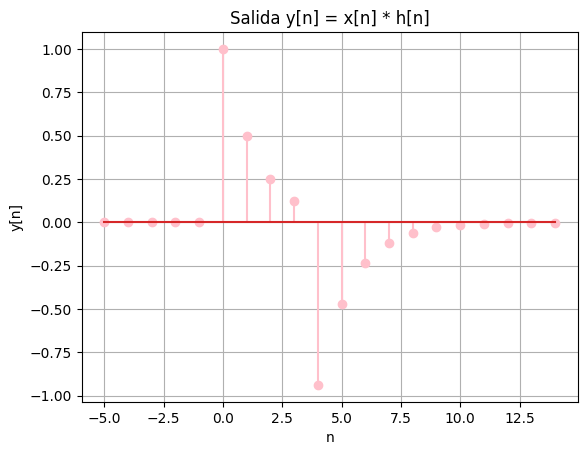

In [49]:
# Rango de n
n = np.arange(-5, 15)

# En esta parte creamos el escalón unitario, cortándola en los negativos. 
u = lambda n: np.where(n >= 0, 1, 0) 

# Creo la señal x[n]
x = (1/2)**n * u(n)

# Hago la señal desplazada x[n-4]
x_shift = (1/2)**(n-4) * u(n-4)

# La salida será la resta de ambas. 
y = x - x_shift

# Gráfico

plt.stem(n, y, linefmt='pink') #Stem sirve para graficar puntos discretos, que son los que queremos observar, y no una línea contirnua. Hace palitos verticales y puntitos, como si fueran las deltas.
plt.xlabel("n")
plt.ylabel("y[n]")
plt.title("Salida y[n] = x[n] * h[n]")
plt.grid()
plt.show()

Obtenemos la diferencia entre una copia normal y una desplazada cuatro lugares, vemos básicamente  4 partes del gráfico. 

En la parte más a la izquierda, Cuando n<0, todo es 0, debido a que el escalón unitario es 0. 

Luego, entre 0 < n < 3 , solo existe x [n] ya que x[n-4] aún es 0, por ello es que se observan los valores positivos, disminuyendo exponencialmente.

En n = 4 


$$
y[4] = x[4] - x[0]
$$

donde:

$$
x[4] = \left(\frac{1}{2}\right)^4 = 0.0625
$$

$$
x[0] = 1
$$

Por lo tanto:

$$
y[4] = 0.0625 - 1 = -0.9375
$$

Obteniendo ese pico negativo que podemos observar en la imagen. 

Luego, para n > 4 , va predominando la resta apagándose cada vez más los valores. 

**C) Sea la señal de entrada:**

$$
x[n] = u[n + 1] - u[n - 2]
$$

Expresar la salida del sistema:

$$
y[n] = x[n] * h[n]
$$

para esta señal de entrada.

![Resolución del primer inciso.](imagen8.jpeg)

Similar al ejercicio anterior, como estamos frente a la función escalón, podemos graficarlo en python e intentar comprender si el resultado es congruente con el esperado.

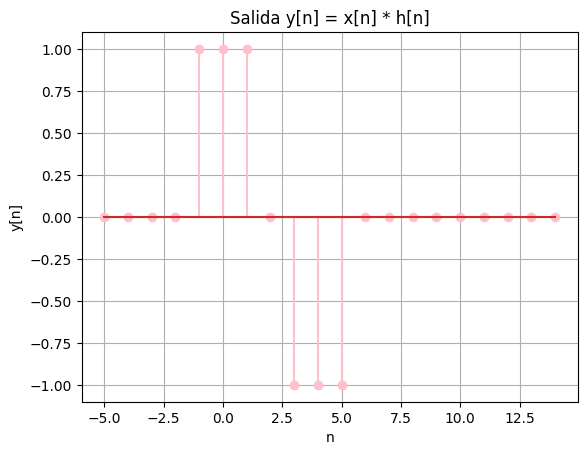

In [51]:
# Rango de n
n = np.arange(-5, 15)

# Escalón unitario
u = lambda n: np.where(n >= 0, 1, 0)

# Señal x[n] = u[n+1] - u[n-2]
x = u(n+1) - u(n-2)

# Señal desplazada x[n-4] = u[n-3] - u[n-6]
x_shift = u(n-3) - u(n-6)

# Salida
y = x - x_shift

# Gráfico
plt.stem(n, y, linefmt='pink')
plt.xlabel("n")
plt.ylabel("y[n]")
plt.title("Salida y[n] = x[n] * h[n]")
plt.grid()
plt.show()

Tendría que observar dos "rectánculos" iguales, pero uno desplazado. 

Cuando n<-1, ningún escalón se haya "prendido" puesto que son restas de 0. Luego entre -1;1 , se encuentra encendido solo el x[n] ya que el x[n-4] aún no puede encenderse. 

En n=2 es cero, debido a que:


$$
y[2] = x[2] - x[2-4] = x[2] - x[-2]
$$

**Si evlúo primero $x[2]$**

Y sabiendo que x[n] se definía como:

$$
x[n] = u[n+1] - u[n-2]
$$

Entonces con n=2

$$
x[2] = u[3] - u[0]
$$

$$
u[3] = 1, \quad u[0] = 1
$$

Y obtenemos: 

$$
x[2] = 1 - 1 = 0
$$


**Luego evalúo: $x[-2]$**

$$
x[-2] = u[-1] - u[-4]
$$


$$
u[-1] = 0, \quad u[-4] = 0
$$

obtengo:

$$
x[-2] = 0 - 0 = 0
$$

$$
y[2] = 0 - 0 = 0
$$

Esto ocurre debido a que la señal original ya se apagó, mientras que la señal corrida aún no inició. Es por ello que se observa un punto nulo, además no hay superposición. 

Entre [3;5] solo se observa la señal corrida, finalmente teniendo solo ceros. Es decir que la señal existe solo en dichos intervalos.